In [39]:
from pathlib import Path

import duckdb

import networkx as nx
import osmnx as ox
import pandas as pd

from plotly import graph_objects as go

import mmlib

# Veículos interessantes
- 0: Resultado do map matching é quase perfeito
- 10: Resultado do map matching sofre de desvio desnecessário
- 33: Resultado do map matching sofre de desvio desnecessário extremo

In [40]:
ROOT_PATH = Path(".").resolve().absolute()
GRAPHHOPPER_BASE_URL = "http://localhost:8989"
GRAPHHOPPER_GPS_ACCURACY = 50  # meters
VEHICLE_ID = 0
SAMPLE_RATE: int | None = 2  # seconds

In [41]:
GROUND_TRUTH_PATH = ROOT_PATH / "sumo/simulations/ohare-chicago/output/fcd.parquet"
NOISE_PARQUET = ROOT_PATH / "sumo/simulations/ohare-chicago/output/fcd_noisy.parquet"
NETWORK_PATH = ROOT_PATH / "networks/filtered/ohare-filtered.osm.xml"

In [42]:
type Coordinate = tuple[float, float]  # (latitude, longitude)

In [43]:
def load_road_dataset(path: Path) -> pd.DataFrame:
    df = duckdb.query(
        f"""                
        SELECT lon, lat, TO_TIMESTAMP(time) AS timestamp, edge_id, raw_edge_id
        FROM '{path}'
        WHERE vehicle_id = {VEHICLE_ID}
        ORDER BY time ASC
        """
    ).to_df()

    if SAMPLE_RATE is not None:
        df = df.resample(f"{SAMPLE_RATE:.2f}s", on="timestamp").first().reset_index()

    return df

In [44]:
gt_df = load_road_dataset(GROUND_TRUTH_PATH)
gt_df

,timestamp,lon,lat,edge_id,raw_edge_id
0,1969-12-31 21:00:06-03:00,-87.885873,41.980497,1181871033,1181871033
1,1969-12-31 21:00:08-03:00,-87.885757,41.980466,1181871033,1181871033
2,1969-12-31 21:00:10-03:00,-87.885756,41.980363,1181871033,1181871033
3,1969-12-31 21:00:12-03:00,-87.885717,41.980193,518291376,518291376
4,1969-12-31 21:00:14-03:00,-87.885717,41.980081,518291376,518291376
5,1969-12-31 21:00:16-03:00,-87.885717,41.980077,518291376,518291376
6,1969-12-31 21:00:18-03:00,-87.885717,41.980077,518291376,518291376
7,1969-12-31 21:00:20-03:00,-87.885717,41.980077,518291376,518291376
8,1969-12-31 21:00:22-03:00,-87.885717,41.980077,518291376,518291376
9,1969-12-31 21:00:24-03:00,-87.885717,41.980077,518291376,518291376


In [45]:
noisy_df = load_road_dataset(NOISE_PARQUET)
noisy_df

,timestamp,lon,lat,edge_id,raw_edge_id
0,1969-12-31 21:00:06-03:00,-87.885855,41.980473,1181871033,1181871033
1,1969-12-31 21:00:08-03:00,-87.885700,41.980420,1181871033,1181871033
2,1969-12-31 21:00:10-03:00,-87.885703,41.980294,1181871033,1181871033
3,1969-12-31 21:00:12-03:00,-87.885643,41.980205,518291376,518291376
4,1969-12-31 21:00:14-03:00,-87.885766,41.980044,518291376,518291376
5,1969-12-31 21:00:16-03:00,-87.885745,41.980116,518291376,518291376
6,1969-12-31 21:00:18-03:00,-87.885687,41.980046,518291376,518291376
7,1969-12-31 21:00:20-03:00,-87.885797,41.980044,518291376,518291376
8,1969-12-31 21:00:22-03:00,-87.885635,41.980101,518291376,518291376
9,1969-12-31 21:00:24-03:00,-87.885779,41.980083,518291376,518291376


In [46]:
gt_gps_coordinates = gt_df[["lat", "lon", "timestamp"]].to_records(index=False).tolist()
gt_points = gt_df[["lat", "lon"]].to_records(index=False).tolist()
gt_edge_ids = gt_df["edge_id"].tolist()

print("GROUND TRUTH: ", len(gt_points), "points")
print("first 3 points:", gt_points[:3])
print("first 3 edge ids:", gt_edge_ids[:3])
print("fist 3 coordinates:", gt_gps_coordinates[:3])

GROUND TRUTH:  58 points
first 3 points: [(41.98049705767809, -87.88587326167055), (41.98046636137595, -87.88575710407007), (41.980362800011314, -87.88575615922878)]
first 3 edge ids: ['1181871033', '1181871033', '1181871033']
fist 3 coordinates: [(41.98049705767809, -87.88587326167055, Timestamp('1969-12-31 21:00:06-0300', tz='America/Fortaleza')), (41.98046636137595, -87.88575710407007, Timestamp('1969-12-31 21:00:08-0300', tz='America/Fortaleza')), (41.980362800011314, -87.88575615922878, Timestamp('1969-12-31 21:00:10-0300', tz='America/Fortaleza'))]


In [47]:
noisy_gps_coordinates = (
    noisy_df[["lat", "lon", "timestamp"]].to_records(index=False).tolist()
)
noisy_points = noisy_df[["lat", "lon"]].to_records(index=False).tolist()
noisy_edge_ids = noisy_df["edge_id"].tolist()

print("NOISY: ", len(noisy_points), "points")
print("first 3 points:", noisy_points[:3])
print("first 3 edge ids:", noisy_edge_ids[:3])
print("first 3 coordinates:", noisy_gps_coordinates[:3])

NOISY:  58 points
first 3 points: [(41.98047268137153, -87.88585487776714), (41.98041959047878, -87.88570035883409), (41.98029425478, -87.88570310433114)]
first 3 edge ids: ['1181871033', '1181871033', '1181871033']
first 3 coordinates: [(41.98047268137153, -87.88585487776714, Timestamp('1969-12-31 21:00:06-0300', tz='America/Fortaleza')), (41.98041959047878, -87.88570035883409, Timestamp('1969-12-31 21:00:08-0300', tz='America/Fortaleza')), (41.98029425478, -87.88570310433114, Timestamp('1969-12-31 21:00:10-0300', tz='America/Fortaleza'))]


In [48]:
matcher = mmlib.graphhopper_matcher(
    GRAPHHOPPER_BASE_URL, gps_accuracy=GRAPHHOPPER_GPS_ACCURACY
)

In [49]:
gpx_data = mmlib.to_gpx(noisy_gps_coordinates)

In [50]:
match_result = matcher.map_match(gpx_data)
match_result

MatchResult(points=[Coordinate(latitude=41.98058, longitude=-87.88576), Coordinate(latitude=41.98031, longitude=-87.88576), Coordinate(latitude=41.98002, longitude=-87.88576), Coordinate(latitude=41.97987, longitude=-87.88575), Coordinate(latitude=41.97986, longitude=-87.88558), Coordinate(latitude=41.98062, longitude=-87.88559), Coordinate(latitude=41.98219, longitude=-87.88559), Coordinate(latitude=41.98227, longitude=-87.88559), Coordinate(latitude=41.98372, longitude=-87.88559), Coordinate(latitude=41.9848, longitude=-87.88558), Coordinate(latitude=41.98983, longitude=-87.88559), Coordinate(latitude=41.99037, longitude=-87.88559), Coordinate(latitude=41.99037, longitude=-87.88529)], edge_ids=['1181871033', '518291376', '518291373', '518291372', '1043374337', '474730116', '1043374338', '1094426120', '1207944097', '642073723', '1094426125', '1094426126'])

In [51]:
ground_truth_edges = set(gt_edge_ids)
matched_edges = set(match_result.edge_ids)
(
    len(matched_edges),
    len(ground_truth_edges),
    len(matched_edges & ground_truth_edges),
    len(matched_edges & ground_truth_edges),
    len(matched_edges.symmetric_difference(ground_truth_edges)),
)

(12, 12, 10, 10, 4)

In [52]:
def plot_trajectories(
    original: list[Coordinate],
    calculated: list[Coordinate],
    title: str = "Tracks",
    original_label: str = "Original",
    calculated_label: str = "Calculated",
    show_original_line: bool = True,
    show_buttons: bool = True,
    center_lat: float | None = None,
    center_lon: float | None = None,
    zoom: float = 14,
) -> None:
    flat_original = [
        (lat, lon, original_label, i) for i, (lat, lon) in enumerate(original)
    ]
    flat_calculated = [
        (lat, lon, calculated_label, i) for i, (lat, lon) in enumerate(calculated)
    ]

    df = pd.DataFrame(
        flat_original + flat_calculated,
        columns=["lat", "lon", "type", "row_num"],
    )

    fig = go.Figure()
    visible_flags = []

    for type_ in [original_label, calculated_label]:
        subset = df[df["type"] == type_].sort_values("row_num")

        # Pontos
        fig.add_trace(
            go.Scattermap(
                lat=subset["lat"],
                lon=subset["lon"],
                mode="markers",
                marker=dict(size=10),
                name=f"{type_} - pontos",
                legendgroup=type_,
                visible=True,
            )
        )
        visible_flags.append(True)

        # Linhas
        show_line = True
        if type_ == original_label and not show_original_line:
            show_line = False
        fig.add_trace(
            go.Scattermap(
                lat=subset["lat"],
                lon=subset["lon"],
                mode="lines",
                line=dict(width=2),
                name=f"{type_} - linha",
                legendgroup=type_,
                visible=show_line,
            )
        )
        visible_flags.append(show_line)

    # Definir centro do mapa
    if center_lat is None or center_lon is None:
        # Usar centro calculado a partir dos dados
        map_center = dict(lat=df["lat"].mean(), lon=df["lon"].mean())
    else:
        # Usar coordenadas fornecidas
        map_center = dict(lat=center_lat, lon=center_lon)

    if show_buttons:
        fig.update_layout(
            updatemenus=[
                dict(
                    type="buttons",
                    direction="right",
                    showactive=True,
                    x=0.5,
                    xanchor="center",
                    y=1,
                    yanchor="top",
                    buttons=[
                        dict(
                            label="Mostrar Nenhuma",
                            method="update",
                            args=[
                                {"visible": [False, False, False, False]},
                                {"mapbox": dict(center=map_center, zoom=zoom)},
                            ],
                        ),
                        dict(
                            label="Mostrar Ambas",
                            method="update",
                            args=[
                                {"visible": [True, show_original_line, True, True]},
                                {"mapbox": dict(center=map_center, zoom=zoom)},
                            ],
                        ),
                        dict(
                            label=f"Apenas {original_label}",
                            method="update",
                            args=[
                                {"visible": [True, show_original_line, False, False]},
                                {"mapbox": dict(center=map_center, zoom=zoom)},
                            ],
                        ),
                        dict(
                            label=f"Apenas {calculated_label}",
                            method="update",
                            args=[
                                {"visible": [False, False, True, True]},
                                {"mapbox": dict(center=map_center, zoom=zoom)},
                            ],
                        ),
                    ],
                )
            ]
        )

    fig.update_layout(
        mapbox_style="open-street-map",
        mapbox=dict(center=map_center, zoom=zoom),
        margin=dict(l=0, r=0, t=80, b=0),
        height=700,
        title=title,
    )

    fig.show()

In [53]:
plot_trajectories(
    original=noisy_points,
    calculated=[pt.to_tuple() for pt in match_result.points],
    title="Map Matching - GraphHopper",
    original_label="Noisy GPS",
    calculated_label="GraphHopper Match",
    show_original_line=False,
    zoom=16,
)

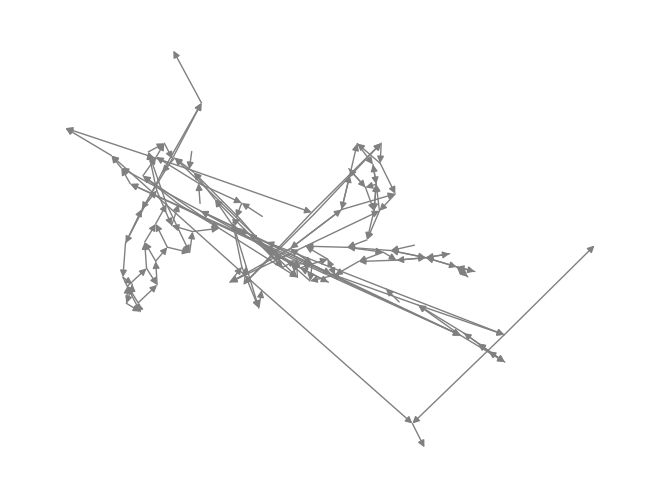

In [54]:
road_graph = ox.graph_from_xml(NETWORK_PATH)
nx.draw(road_graph, node_size=0, edge_color="gray")

In [55]:
def plot_map_matching_from_osmid(
    graph: nx.Graph,
    ground_truth_osmid_path: list[str],
    map_matched_osmid_path: list[str],
):
    """
    Plots map matching results where paths are defined by lists of OSM IDs.

    This function correctly handles graphs where the 'osmid' edge attribute
    can be a list of IDs (common with OSMnx simplification). It builds a
    reverse index to map any single OSM ID back to its corresponding graph edge.

    Args:
        graph (nx.Graph): The street network graph. Assumed to have:
                          - Nodes with 'x' and 'y' attributes.
                          - Edges with an 'osmid' attribute, which can be an
                            ID or a list of IDs.
        ground_truth_osmid_path (list): List of OSM IDs for the true path.
        map_matched_osmid_path (list): List of OSM IDs for the matched path.
    """
    # --- 1. Get Node Positions ---
    try:
        pos = {node: (data["x"], data["y"]) for node, data in graph.nodes(data=True)}
    except KeyError:
        raise ValueError("Nodes in the graph must have 'x' and 'y' attributes.")

    # --- 2. Build the OSM ID to Edge Reverse Map (THE KEY STEP) ---
    # This map allows us to find the edge (u, v) from a single OSM ID.
    osmid_to_edge_map = {}
    for u, v, data in graph.edges(data=True):
        if "osmid" in data:
            osmid_val = data["osmid"]
            # Handle both single IDs and lists of IDs gracefully
            if isinstance(osmid_val, list):
                for osmid in osmid_val:
                    osmid_to_edge_map[str(osmid)] = (u, v)
            else:  # It's a single ID
                osmid_to_edge_map[str(osmid_val)] = (u, v)
        else:
            print(f"Warning: Edge ({u}, {v}) missing 'osmid' attribute.")

    # --- 3. Prepare Sets for Quick Comparison ---
    ground_truth_set = set(ground_truth_osmid_path)
    map_matched_set = set(map_matched_osmid_path)

    correct_osmid_set = ground_truth_set & map_matched_set
    missed_osmid_set = ground_truth_set - map_matched_set
    extra_osmid_set = map_matched_set - ground_truth_set

    print(
        f"Correctly Matched OSM IDs: {len(correct_osmid_set)}"
        f"\nMissed OSM IDs: {len(missed_osmid_set)}"
        f"\nExtra OSM IDs: {len(extra_osmid_set)}"
    )

    road_network_osmid_set = set(osmid_to_edge_map.keys())
    in_gt_but_not_in_network = ground_truth_set - road_network_osmid_set
    in_matched_but_not_in_network = map_matched_set - road_network_osmid_set

    print(
        f"OSM IDs in Ground Truth but not in Road Network: {len(in_gt_but_not_in_network)}"
        f"\nOSM IDs in Matched Path but not in Road Network: {len(in_matched_but_not_in_network)}"
    )

    # --- 4. Create Plotly Traces ---
    fig_data = []

    # 4.1. Background Graph Trace
    x_edges_bg, y_edges_bg = [], []
    for u, v in graph.edges():
        x_edges_bg.extend([pos[u][0], pos[v][0], None])
        y_edges_bg.extend([pos[u][1], pos[v][1], None])
    fig_data.append(
        go.Scatter(
            x=x_edges_bg,
            y=y_edges_bg,
            mode="lines",
            line=dict(color="lightgray", width=1),
            hoverinfo="none",
            name="Street Network",
        )
    )

    # 4.2. Helper function to create traces for path segments
    def create_path_trace(osmid_set: set, color: str, name: str, width: int = 4):
        x_coords, y_coords = [], []
        for osmid in osmid_set:
            osmid_str = str(osmid)
            if osmid_str in osmid_to_edge_map:
                u, v = osmid_to_edge_map[osmid_str]
                x_coords.extend([pos[u][0], pos[v][0], None])
                y_coords.extend([pos[u][1], pos[v][1], None])
            else:
                # This warning will now tell you if an OSM ID from your path is truly missing from the graph
                print(
                    f"Warning: OSM ID {osmid} from path not found in the graph's edge data."
                )

        return go.Scatter(
            x=x_coords,
            y=y_coords,
            mode="lines",
            line=dict(color=color, width=width),
            name=name,
        )

    # 4.3. Add traces for each category of edges
    fig_data.append(create_path_trace(correct_osmid_set, "green", "Correctly Matched"))
    fig_data.append(create_path_trace(missed_osmid_set, "red", "Missed by Algorithm"))
    fig_data.append(
        create_path_trace(extra_osmid_set, "blue", "Incorrectly Added by Algorithm")
    )

    summary_text = (
        f"Correct: {len(correct_osmid_set)}<br>"
        f"Missed: {len(missed_osmid_set)}<br>"
        f"Extra: {len(extra_osmid_set)}"
    )

    # --- 5. Finalize Figure Layout ---
    fig = go.Figure(data=fig_data)
    fig.update_layout(
        title="Map Matching Visualization from OSM IDs",
        showlegend=True,
        legend=dict(x=0.01, y=0.99, bordercolor="Black", borderwidth=1),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(
            showgrid=False,
            zeroline=False,
            showticklabels=False,
            scaleanchor="x",
            scaleratio=1,
        ),
        plot_bgcolor="white",
        margin=dict(l=10, r=10, t=40, b=10),
        annotations=[
            dict(
                text=summary_text,
                xref="paper",
                yref="paper",
                x=0.01,
                y=0.75,
                showarrow=False,
                align="left",
                bordercolor="black",
                borderwidth=1,
                bgcolor="white",
                opacity=0.8,
            )
        ],
    )
    fig.show()

In [56]:
plot_map_matching_from_osmid(
    graph=road_graph,
    ground_truth_osmid_path=gt_edge_ids,
    map_matched_osmid_path=match_result.edge_ids,
)

Correctly Matched OSM IDs: 10
Missed OSM IDs: 2
Extra OSM IDs: 2
OSM IDs in Ground Truth but not in Road Network: 2
OSM IDs in Matched Path but not in Road Network: 0
